$$
X = \begin{bmatrix}x_0 & x_1 & \cdots & x_{T-2}\end{bmatrix},
\qquad
Y = \begin{bmatrix}x_1 & x_2 & \cdots & x_{T-1}\end{bmatrix}
$$

$$
X = U\Sigma V^*
$$

$$
U_r = U[:,1\!:\!r],
\qquad
\Sigma_r = \Sigma[1\!:\!r,1\!:\!r],
\qquad
V_r = V[:,1\!:\!r]
$$

$$
\widetilde A = U_r^* Y V_r \Sigma_r^{-1}
$$

$$
\widetilde A W = W\Lambda
$$

$$
\Phi = Y V_r \Sigma_r^{-1} W
$$

$$
B = \Phi^{\dagger} X
$$

$$
\widehat X = \Phi \Lambda B
$$

In [4]:
from pathlib import Path
import sys

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from tdmd import dmd

plt.style.use("seaborn-v0_8-whitegrid")

In [6]:
def make_plasma(nx=100, ny=100, nt=100):
    x = jnp.linspace(-1.0, 1.0, nx)
    y = jnp.linspace(-1.0, 1.0, ny)
    t = jnp.linspace(0.0, 4.0 * jnp.pi, nt)
    X, Y, T = jnp.meshgrid(x, y, t, indexing="ij")

    Xf = 5.0 * X - 5.0
    Yf = 5.0 * Y - 5.0
    R = jnp.sqrt(Xf**2 + Yf**2)
    Theta = jnp.arctan2(Yf, Xf + 1.0e-6)

    Z = (
        7.0 * jnp.sin(1.7 * Xf + 0.9 * T)
        + 6.0 * jnp.cos(1.3 * Yf - 1.2 * T)
        + 5.0 * jnp.sin(0.9 * (Xf + Yf) + 0.7 * T)
        + 4.0 * jnp.cos(2.2 * R - 1.8 * T)
        + 3.0 * jnp.sin(3.0 * Theta + 0.6 * R - 1.1 * T)
        + 2.5 * jnp.cos(1.8 * (Xf - Yf) + 0.3 * R + 0.8 * T)
    )
    return Z, t


def split_shifted_matrix(sequence):
    X = sequence[:, :, :-1].reshape(sequence.shape[0] * sequence.shape[1], -1)
    Y = sequence[:, :, 1:].reshape(sequence.shape[0] * sequence.shape[1], -1)
    return X, Y


def relative_error(target, approx):
    return float(jnp.linalg.norm(target - approx) / jnp.linalg.norm(target))


def draw_frame(ax, frame, title, cmap="magma"):
    image = ax.imshow(np.asarray(jnp.real(frame)), origin="lower", cmap=cmap)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return image

sequence shape = (96, 96, 80)
modes shape = (9216, 8)
eigenvalues shape = (8,)
relative shift-fit error = 8.1631e-03


/tmp/ipykernel_7124/3572311219.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


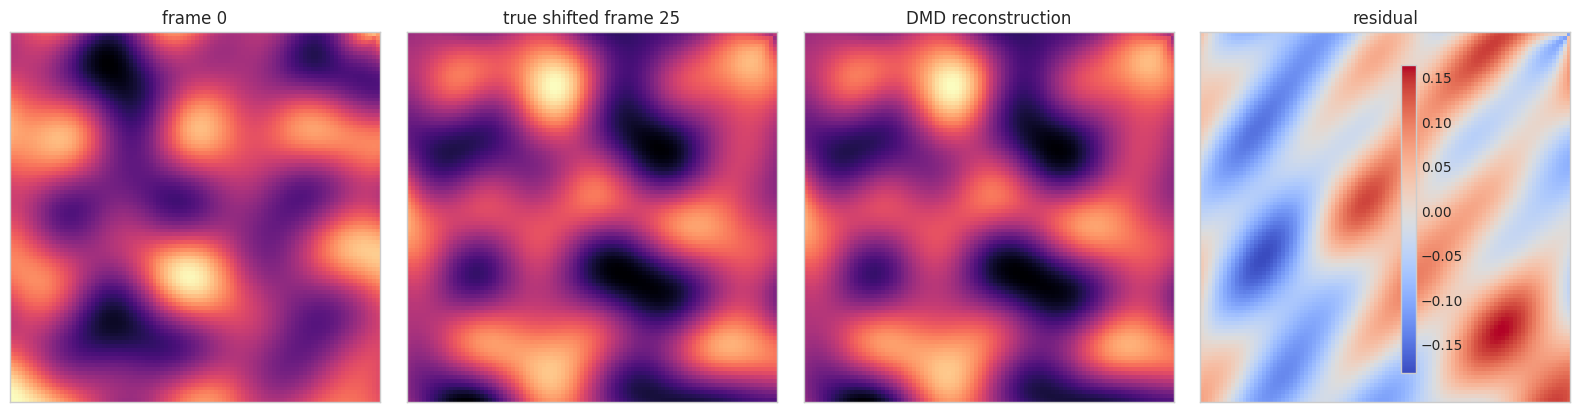

In [7]:
Z, t = make_plasma(nx=96, ny=96, nt=80)
X, Y = split_shifted_matrix(Z)

rank = 20
energy_threshold = 0.995
svd_threshold = 1.0e-8

modes, eigenvalues = dmd(
    X,
    Y,
    rank=rank,
    energy_threshold=energy_threshold,
    svd_threshold=svd_threshold,
)

coefficients = jnp.linalg.lstsq(modes, X, rcond=None)[0]
X_hat = modes @ (eigenvalues[:, None] * coefficients)
Y_hat = X_hat.reshape(Z.shape[0], Z.shape[1], Z.shape[2] - 1)
Y_true = Z[:, :, 1:]

fit_error = relative_error(Y_true, Y_hat)
frame_idx = 24

print(f"sequence shape = {tuple(Z.shape)}")
print(f"modes shape = {tuple(modes.shape)}")
print(f"eigenvalues shape = {tuple(eigenvalues.shape)}")
print(f"relative shift-fit error = {fit_error:.4e}")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img0 = draw_frame(axes[0], Z[:, :, 0], "frame 0")
img1 = draw_frame(axes[1], Y_true[:, :, frame_idx], f"true shifted frame {frame_idx + 1}")
img2 = draw_frame(axes[2], Y_hat[:, :, frame_idx], "DMD reconstruction")
img3 = draw_frame(
    axes[3], Y_true[:, :, frame_idx] - Y_hat[:, :, frame_idx], "residual", cmap="coolwarm"
)
fig.colorbar(img3, ax=axes, fraction=0.02, pad=0.02)
plt.tight_layout()